# Drone Surveillance & Object Detection System (YOLOv8)
**พัฒนาและจัดระเบียบโครงสร้างใหม่สำหรับ Google Colab & GitHub**

โน้ตบุ๊กเล่มนี้ถูกรวมศูนย์โค้ดและแยกออกเป็นโครงสร้างที่ชัดเจน เพื่อป้องกันปัญหา `NameError` หรือปัญหาไลบรารีสูญหายเมื่อเปิดเซสชันใหม่บน Google Colab

### คำแนะนำก่อนเริ่มใช้งาน:
1. ไปที่เมนูด้านซ้าย คลิกไอคอน **โฟลเดอร์ (Files)**
2. ลากไฟล์ภาพที่ต้องการสแกนเข้ามาวาง และตั้งชื่อไฟล์ว่า `object.png`
3. กดเมนู **Runtime (รันไทม์) -> Run all (รันทั้งหมด)** โค้ดจะทำงานตั้งแต่ต้นจนจบโดยอัตโนมัติ

---
## 📦 SECTION 1: SYSTEM INSTALLATION (ติดตั้งไลบรารี)

In [9]:
# ==============================================================================
# ตรวจสอบและติดตั้งชุดคำนวณและโมเดลสำหรับการสแกนวัตถุ
# ==============================================================================
print("📦 [SYSTEM] กำลังดำเนินการติดตั้งไลบรารีภายนอกที่จำเป็น...")

# ติดตั้ง OpenCV สำหรับการจัดการรูปภาพแบบไร้ GUI และ Ultralytics สำหรับ YOLOv8
!pip install -q opencv-python-headless
!pip install -q ultralytics

print("✅ [SYSTEM] การติดตั้งเสร็จสิ้น เครื่องจำลองพร้อมประมวลผลแล้ว!")

📦 [SYSTEM] กำลังดำเนินการติดตั้งไลบรารีภายนอกที่จำเป็น...
✅ [SYSTEM] การติดตั้งเสร็จสิ้น เครื่องจำลองพร้อมประมวลผลแล้ว!


---
## 🗂️ SECTION 2: ENVIRONMENT IMPORTS (นำเข้าโมดูลหลัก)

In [10]:
# ==============================================================================
# รวมศูนย์การ Import ทั้งหมดไว้ที่เดียว เพื่อป้องกันปัญหา NameError ระหว่างบล็อก
# ==============================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

print("🗂️ [SYSTEM] นำเข้าไลบรารีแกนหลัก (OpenCV, NumPy, Matplotlib, YOLO) สำเร็จ!")

🗂️ [SYSTEM] นำเข้าไลบรารีแกนหลัก (OpenCV, NumPy, Matplotlib, YOLO) สำเร็จ!


---
## 🛠️ SECTION 3: UTILITY FUNCTIONS (ฟังก์ชันแสดงผลระบบตรวจการณ์)

In [7]:
# ==============================================================================
# ฟังก์ชันสากลสำหรับแปลงระบบสีภาพและจัดรูปแบบกราฟผลลัพธ์
# ==============================================================================
def display_drone_surveillance_result(image, title="Drone Reconnaissance"):
    """
    แปลงระบบสีภาพจาก BGR (OpenCV) เป็น RGB (Matplotlib)
    และทำการปิดเส้นแกนสเกลภาพ เพื่อความสวยงามและเป็นระเบียบบนหน้าจอ
    """
    if image is None:
        print(f"❌ [ERROR] ไม่พบข้อมูลรูปภาพสำหรับหัวข้อ: {title}")
        return

    # แปลงสีของภาพ
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ตั้งค่า Frame และแสดงผลกราฟรูปภาพ
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    plt.title(title, fontsize=14, fontweight='bold', color='#1a5f7a')
    plt.axis("off")  # ลบเส้นขอบตัวเลขแกน X-Y
    plt.show()

print("🛠️ [SYSTEM] ประกาศและผูกฟังก์ชัน display_drone_surveillance_result เรียบร้อย!")

🛠️ [SYSTEM] ประกาศและผูกฟังก์ชัน display_drone_surveillance_result เรียบร้อย!


---
## 🧠 SECTION 4: CORE AI DETECTION LOGIC (ระบบสแกนและประมวลผลวัตถุ)

🔄 [SYSTEM] เปิดระบบเรดาร์และสแกนพิกัดเป้าหมายจากมุมสูง...
🧠 [AI PROCESSING] โมเดลกำลังสแกนประมวลผลค้นหา Personnel & Vehicles...
✅ [SUCCESS] ตรวจสอบเสร็จสิ้น! พบวัตถุเป้าหมายในเซกเตอร์รวม: 11 รายการ


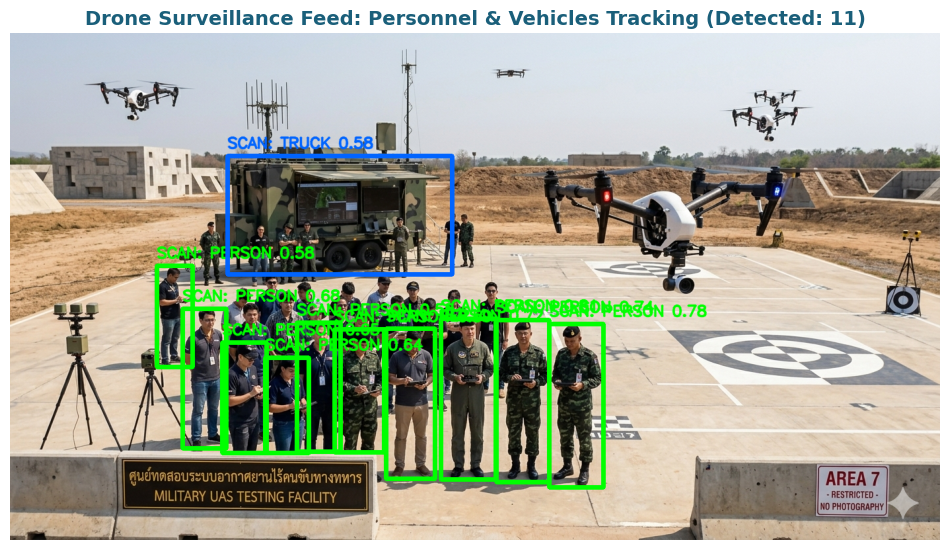

In [8]:
# ==============================================================================
# โครงสร้างหลัก: ดาวน์โหลดโมเดล คัดกรองเป้าหมาย และระบุพิกัดลงบนภาพถ่ายทางอากาศ
# ==============================================================================
print("🔄 [SYSTEM] เปิดระบบเรดาร์และสแกนพิกัดเป้าหมายจากมุมสูง...")

# 1. โหลดโมเดล YOLOv8 Pre-trained (Small เวอร์ชัน เพื่อความแม่นยำสูงในระดับแท็กทิคัล)
model_drone = YOLO('yolov8s.pt')

# 2. ตรวจสอบไฟล์ภาพนำเข้าจากโดรนในระบบชั่วคราว
drone_capture_path = "object.png"

if not os.path.exists(drone_capture_path):
    print(f"❌ [ALERT] ระบบหยุดทำงานชั่วคราว: ไม่พบไฟล์ภาพ '{drone_capture_path}'")
    print("💡 คำแนะนำ: กรุณาลากไฟล์รูปภาพมาวางที่ช่องแถบเครื่องมือ 'Files' ฝั่งซ้าย แล้วตั้งชื่อว่า object.png จากนั้นกดรันเซลล์นี้ใหม่อีกครั้งคราบบ")
else:
    # อ่านข้อมูลรูปภาพ
    raw_image = cv2.imread(drone_capture_path)
    processed_feed = raw_image.copy()  # สำเนาภาพเพื่อไม่ให้กระทบรูปต้นฉบับ

    # 3. กำหนดค่ามาตรฐานพารามิเตอร์การคัดกรอง
    confidence_limit = 0.50  # คัดเฉพาะความมั่นใจของ AI เกิน 50%
    nms_iou_limit = 0.40     # ลดกรอบตรวจจับที่ทับซ้อนกันหนาแน่นเกินไป (NMS)

    # 🎯 เจาะจงคลาสเป้าหมายตรวจการณ์: มนุษย์ และ ยานพาหนะเดินทาง
    surveillance_targets = ["person", "car", "truck", "bus", "motorcycle", "bicycle"]

    print("🧠 [AI PROCESSING] โมเดลกำลังสแกนประมวลผลค้นหา Personnel & Vehicles...")

    # ส่งวิเคราะห์อินเฟอเรนซ์
    drone_predictions = model_drone.predict(
        source=processed_feed,
        conf=confidence_limit,
        iou=nms_iou_limit,
        save=False,
        show=False,
        verbose=False
    )

    # 4. ถอดรหัสตำแหน่งและสร้างสัญลักษณ์ผลลัพธ์บนภาพ
    coco_names = model_drone.names
    detected_boxes = drone_predictions[0].boxes
    tracked_count = 0

    for item in detected_boxes:
        object_conf = float(item.conf[0])
        object_class_id = int(item.cls[0])
        object_label = coco_names[object_class_id]

        # ดึงพิกัดมุมกรอบ [x1, y1, x2, y2]
        x1, y1, x2, y2 = item.xyxy[0].cpu().numpy().astype(int)

        # กรองวัตถุที่ไม่อยู่ในเงื่อนไขการตรวจการณ์ออก
        if object_label not in surveillance_targets:
            continue

        tracked_count += 1

        # 🎨 ออกแบบแยกเฉดสีจำแนก: มนุษย์ (สีเขียวตรวจการณ์) vs ยานพาหนะ (สีน้ำเงินยุทธวิธี)
        if object_label == "person":
            bounding_box_color = (0, 255, 0)       # สีเขียวสด
        else:
            bounding_box_color = (255, 100, 0)     # สีน้ำเงิน/ฟ้า

        # วาดเส้นกรอบพิกัดสี่เหลี่ยมความหนา 5 (เหมาะสำหรับมองเห็นระยะไกลจากมุมสูง)
        cv2.rectangle(processed_feed, (x1, y1), (x2, y2), bounding_box_color, 5)

        # ปรับแต่ง Text UI: "SCAN: CLASSNAME (CONFIDENCE)"
        ui_text = f"SCAN: {object_label.upper()} {object_conf:.2f}"

        # ตรวจสอบตำแหน่งข้อความไม่ให้ตกขอบบนสุดของภาพ
        adjusted_text_y = y1 - 12 if y1 > 25 else y1 + 28

        # เขียนคำกำกับลงไปบนภาพ
        cv2.putText(processed_feed, ui_text, (x1, adjusted_text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, bounding_box_color, 2, cv2.LINE_AA)

    print(f"✅ [SUCCESS] ตรวจสอบเสร็จสิ้น! พบวัตถุเป้าหมายในเซกเตอร์รวม: {tracked_count} รายการ")

    # 5. เรียกเปิดฟังก์ชันเพื่อวาดแสดงภาพและสถิติสุดท้ายบน Colab
    display_drone_surveillance_result(
        processed_feed,
        title=f"Drone Surveillance Feed: Personnel & Vehicles Tracking (Detected: {tracked_count})"
    )